In [30]:
import random
from collections import deque
from pathlib import Path

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output
from gymnasium import ObservationWrapper
from gymnasium.spaces import Box
from gymnasium.wrappers import FrameStackObservation
from gymnasium.wrappers import AtariPreprocessing
import cv2

In [31]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, obs, action, reward, next_obs, done):
        self.buffer.append((obs, action, reward, next_obs, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, actions, rewards, next_obs, dones = zip(*batch)

        obs = np.asarray(obs, dtype=np.float32)
        next_obs = np.asarray(next_obs, dtype=np.float32)

        obs = torch.from_numpy(obs) / 255.0
        next_obs = torch.from_numpy(next_obs) / 255.0

        actions = torch.tensor(actions, dtype=torch.long)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32)

        return obs, actions, rewards, next_obs, dones

    def __len__(self):
        return len(self.buffer)

In [32]:
class DQN(nn.Module):
    def __init__(self, obs_shape, n_actions):
        super().__init__()

        # obs_shape should be (4, 84, 84)
        c, h, w = obs_shape

        self.conv = nn.Sequential(
            nn.Conv2d(c, 32, kernel_size=8, stride=4),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, c, h, w)
            conv_out_size = self.conv(dummy).view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [33]:
class Agent:
    def __init__(
        self,
        obs_shape,
        n_actions,
        device,
        gamma=0.99,
        lr=1e-4,
    ):
        self.device = torch.device(device)
        self.n_actions = n_actions
        self.gamma = gamma

        # Online network: updated by gradient descent
        self.q_net = DQN(obs_shape, n_actions).to(self.device)

        # Target network: periodically copied from q_net
        self.target_net = DQN(obs_shape, n_actions).to(self.device)

        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(
            self.q_net.parameters(),
            lr=lr,
        )

    def select_action(self, obs, epsilon, action_space):
        """
        Select a random action with probability epsilon.
        Otherwise, select the action with the largest predicted Q-value.
        """
        if random.random() < epsilon:
            return action_space.sample()

        obs_t = torch.as_tensor(
            obs,
            dtype=torch.float32,
            device=self.device,
        )

        # Add the batch dimension:
        # (channels, height, width) -> (1, channels, height, width)
        obs_t = obs_t.unsqueeze(0) / 255.0

        self.q_net.eval()

        with torch.no_grad():
            q_values = self.q_net(obs_t)

        return q_values.argmax(dim=1).item()

    def learn(self, batch):
        """
        Perform one DQN gradient update.

        ReplayBuffer returns CPU tensors. Only this sampled minibatch
        is transferred to the selected training device.
        """
        obs, actions, rewards, next_obs, dones = (
            tensor.to(self.device)
            for tensor in batch
        )

        self.q_net.train()

        # Q(s, a) for the actions actually taken
        q_values = self.q_net(obs)

        action_q_values = q_values.gather(
            dim=1,
            index=actions.unsqueeze(1),
        ).squeeze(1)

        # Bellman targets:
        # reward + gamma * max_a Q_target(next_state, a)
        with torch.no_grad():
            next_q_values = self.target_net(next_obs)
            max_next_q_values = next_q_values.max(dim=1).values

            targets = (
                rewards
                + self.gamma
                * max_next_q_values
                * (1.0 - dones)
            )

        # Huber loss is commonly used for DQN because it is less
        # sensitive to large TD errors than ordinary MSE.
        loss = F.smooth_l1_loss(
            action_q_values,
            targets,
        )

        self.optimizer.zero_grad()
        loss.backward()

        # Helps prevent unusually large gradient updates.
        torch.nn.utils.clip_grad_norm_(
            self.q_net.parameters(),
            max_norm=10.0,
        )

        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        """
        Copy the online network weights into the target network.
        """
        self.target_net.load_state_dict(
            self.q_net.state_dict()
        )
        self.target_net.eval()

In [34]:
def make_env(visualize=False, seed=42):
    gym.register_envs(ale_py)

    env = gym.make(
        "ALE/Breakout-v5",
        frameskip=1,
        render_mode="human" if visualize else None,
    )

    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=False,
        grayscale_obs=True,
        grayscale_newaxis=False,
        scale_obs=False,
    )
    env = FrameStackObservation(env, stack_size=4)

    obs, info = env.reset(seed=seed)
    return env, obs, info

In [35]:
from collections import Counter


def evaluate(agent, episodes=5, max_steps=5000):
    env, obs, info = make_env(visualize=True)

    scores = []
    

    for episode in range(episodes):
        obs, info = env.reset()
        action_counts = Counter()
        # launch ball
        obs, reward, terminated, truncated, info = env.step(1)

        total_reward = 0
        lives = info.get("lives", 0)

        for step in range(max_steps):
            action = agent.select_action(
                obs,
                epsilon=0.01,
                action_space=env.action_space,
            )

            action_counts[action] += 1

            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

            done = terminated or truncated
            new_lives = info.get("lives", lives)

            if new_lives < lives and not done:
                obs, fire_reward, terminated, truncated, info = env.step(1)
                total_reward += fire_reward
                done = terminated or truncated

            lives = info.get("lives", new_lives)

            if done:
                break

        scores.append(total_reward)
        print(f"Episode {episode + 1}: {total_reward}")
        print(action_counts)

    print(f"Average reward: {np.mean(scores):.2f}")
    return scores

In [36]:
import numpy as np

def moving_average(values, window=20):
    if len(values) < window:
        return []

    return np.convolve(
        values,
        np.ones(window) / window,
        mode="valid"
    )

In [37]:
def plot_training(episode_rewards, losses):

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)

    plt.plot(
        episode_rewards,
        alpha=0.3,
        label="Episode Reward"
    )

    if len(episode_rewards) >= 20:
        plt.plot(
            moving_average(episode_rewards, 20),
            linewidth=2,
            label="20 Episode Moving Average"
        )

    plt.title("Episode Reward")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(losses)
    plt.title("DQN Loss")
    plt.xlabel("Gradient Update")
    plt.ylabel("MSE Loss")

    plt.tight_layout()
    plt.show()

In [38]:
def save_checkpoint(path, agent, epsilon, step, episode, episode_rewards, losses):
    checkpoint = {
        "q_net_state_dict": agent.q_net.state_dict(),
        "optimizer_state_dict": agent.optimizer.state_dict(),
        "epsilon": epsilon,
        "step": step,
        "episode": episode,
        "episode_rewards": episode_rewards,
        "losses": losses,
        "target_net_state_dict": agent.target_net.state_dict()
    }

    torch.save(checkpoint, path)
    print(f"Saved checkpoint to {path}")

In [39]:
def load_checkpoint(path, agent, device):
    checkpoint = torch.load(
        path,
        map_location=device,
        weights_only=False,
    )

    agent.q_net.load_state_dict(
        checkpoint["q_net_state_dict"]
    )

    agent.target_net.load_state_dict(
        checkpoint["target_net_state_dict"]
    )

    agent.optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    agent.q_net.train()
    agent.target_net.eval()

    print(f"Loaded checkpoint from {path}")

    return {
        "epsilon": checkpoint["epsilon"],
        "step": checkpoint["step"],
        "episode": checkpoint["episode"],
        "episode_rewards": checkpoint["episode_rewards"],
        "losses": checkpoint["losses"],
    }

In [44]:
def train(
    agent,
    env,
    replay_buffer,
    num_steps=500_000,
    batch_size=64,
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.999995,
    save_every=25_000,
    checkpoint_path="breakout_dqn_checkpoint.pt",
    start_step=0,
    start_episode=0,
    target_update_every=1_000,
    episode_rewards=None,
    losses=None,
    learning_starts=20_000,
):
    """
    Train a DQN agent for a fixed number of environment steps.

    Gracefully handles a user interrupt by saving a checkpoint and
    returning the current agent and training history without printing
    a KeyboardInterrupt traceback.
    """

    obs, info = env.reset()

    # Start Breakout by pressing FIRE.
    obs, _, terminated, truncated, info = env.step(1)

    if terminated or truncated:
        obs, info = env.reset()
        obs, _, terminated, truncated, info = env.step(1)

    lives = info.get("lives", 0)

    episode_reward = 0.0
    episode = start_episode
    update_count = 0
    latest_loss = None

    if episode_rewards is None:
        episode_rewards = []

    if losses is None:
        losses = []

    minimum_buffer_size = max(
        learning_starts,
        batch_size,
    )

    # Number of completed environment steps.
    completed_steps = start_step

    try:
        for local_step in range(num_steps):
            global_step = start_step + local_step

            action = agent.select_action(
                obs,
                epsilon,
                env.action_space,
            )

            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            new_lives = info.get("lives", lives)

            # Relaunch the ball after losing a life.
            if new_lives < lives and not done:
                next_obs, fire_reward, terminated, truncated, info = env.step(1)

                reward += fire_reward
                done = terminated or truncated

            lives = info.get("lives", new_lives)

            replay_buffer.add(
                obs,
                action,
                reward,
                next_obs,
                done,
            )

            episode_reward += reward

            if len(replay_buffer) >= minimum_buffer_size:
                batch = replay_buffer.sample(batch_size)
                latest_loss = agent.learn(batch)

                losses.append(latest_loss)
                update_count += 1

                if update_count % target_update_every == 0:
                    agent.update_target_network()

            if done:
                episode_rewards.append(episode_reward)

                episode += 1
                episode_reward = 0.0

                obs, info = env.reset()

                # Launch the ball at the beginning of the new episode.
                obs, _, terminated, truncated, info = env.step(1)

                if terminated or truncated:
                    obs, info = env.reset()
                    obs, _, terminated, truncated, info = env.step(1)

                lives = info.get("lives", 0)

            else:
                obs = next_obs

            epsilon = max(
                epsilon_min,
                epsilon * epsilon_decay,
            )

            # This step has now completed successfully.
            completed_steps = global_step + 1

            if local_step % 500 == 0:
                clear_output(wait=True)

                print(f"Device: {agent.device}")
                print(f"Global step: {completed_steps:,}")
                print(f"Local step: {local_step:,}")
                print(f"Episode: {episode:,}")
                print(f"Gradient updates this run: {update_count:,}")
                print(f"Epsilon: {epsilon:.4f}")
                print(f"Replay buffer size: {len(replay_buffer):,}")

                if latest_loss is not None:
                    print(f"Latest loss: {latest_loss:.5f}")

                if episode_rewards:
                    print(
                        "Latest episode reward: "
                        f"{episode_rewards[-1]:.2f}"
                    )

                plot_training(
                    episode_rewards,
                    losses,
                )

            if (
                completed_steps > 0
                and completed_steps % save_every == 0
            ):
                save_checkpoint(
                    checkpoint_path,
                    agent,
                    epsilon,
                    completed_steps,
                    episode,
                    episode_rewards,
                    losses,
                )

    except KeyboardInterrupt:
        print("\nTraining interrupted by user.")
        print(f"Saving progress at step {completed_steps:,}...")

        save_checkpoint(
            checkpoint_path,
            agent,
            epsilon,
            completed_steps,
            episode,
            episode_rewards,
            losses,
        )

        print("Checkpoint saved successfully.")

        return (
            agent,
            epsilon,
            episode_rewards,
            losses,
        )

    # Reached num_steps normally.
    save_checkpoint(
        checkpoint_path,
        agent,
        epsilon,
        completed_steps,
        episode,
        episode_rewards,
        losses,
    )

    print(f"Training completed at step {completed_steps:,}.")

    return (
        agent,
        epsilon,
        episode_rewards,
        losses,
    )

In [41]:
visualize = False

env, obs, info = make_env(visualize=visualize, seed=42)

CHECKPOINT_PATH = "breakout_dqn_checkpoint.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"
agent = Agent(obs.shape, env.action_space.n, device)
replay_buffer = ReplayBuffer(capacity=50_000)
epsilon = 0.1
start_step=0
start_episode=0
episode_rewards=[]
losses=[]
learning_starts = 20_000

In [42]:

if Path(CHECKPOINT_PATH).exists():
    checkpoint = load_checkpoint(
        CHECKPOINT_PATH,
        agent,
        device,
    )

    epsilon = checkpoint["epsilon"]
    start_step=checkpoint["step"]
    start_episode=checkpoint["episode"]
    episode_rewards=checkpoint["episode_rewards"]
    losses=checkpoint["losses"]
    learning_starts = 0

    print(f"Resuming from step {checkpoint['step']}")

else:
    print("No checkpoint found. Starting fresh.")

Loaded checkpoint from breakout_dqn_checkpoint.pt
Resuming from step 575000


In [ ]:
# #Laptop

# agent, epsilon, episode_rewards, losses = train(
#     agent,
#     env,
#     replay_buffer,
#     num_steps=5000,
#     epsilon=epsilon,
#     start_step=start_step,
#     start_episode=start_episode,
#     episode_rewards=episode_rewards,
#     losses=losses,
# )

Device: cuda
Global step: 575,001
Local step: 0
Episode: 1,780
Gradient updates this run: 1
Epsilon: 0.1000
Replay buffer size: 659
Latest loss: 0.00074
Latest episode reward: 9.00


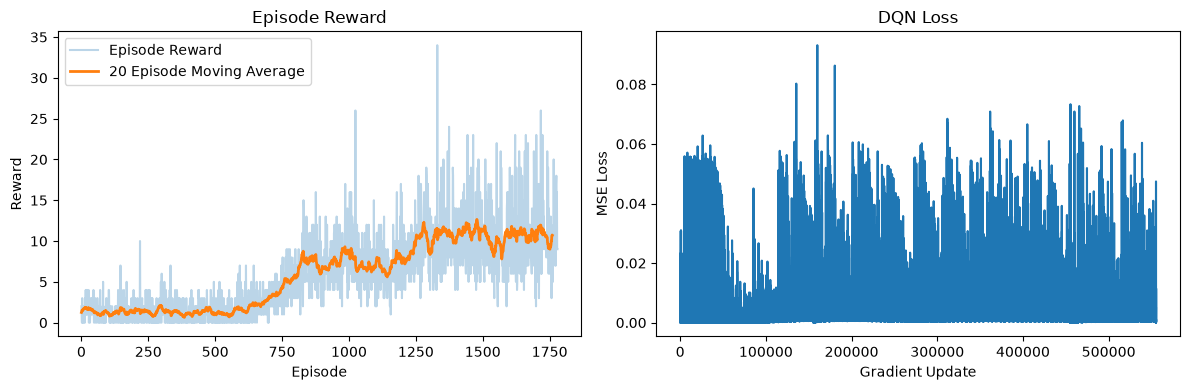


Training interrupted by user.
Saving progress at step 575,330...
Saved checkpoint to breakout_dqn_checkpoint.pt
Checkpoint saved successfully.


In [45]:
# PC

agent, epsilon, episode_rewards, losses = train(
    agent,
    env,
    replay_buffer,
    num_steps=500_000,
    batch_size=64,
    save_every=25_000,
    target_update_every=5_000,
    learning_starts=learning_starts,
    epsilon=epsilon,
    start_step=start_step,
    start_episode=start_episode,
    episode_rewards=episode_rewards,
    losses=losses,
)

In [ ]:
evaluate(agent, episodes=5)